# Task 4.5 — Geo Mean HAI Across All Variants (D28)

**4.5 Predict antibody breadth — all variants (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI / Measure: Geo mean / Metric: Spearman correlation
* Full description: Geometric mean HAI titer across all measured variants at Day 28

---

## Design notes

**y-values:** `breadth_delta` = log2(geomean HAI D28) − log2(geomean HAI D0), computed from the 17 challenge strains (16/17 have D28 data in training; `H3N2 A/Massachusetts/18/2022` is missing). Only participants with ≥ `MIN_STRAINS` strains at both D0 and D28 are included. Evaluation reconstructs final log2 D28 geomeans as `geomean_d0 + predicted_breadth_delta` before computing Spearman against actual `geomean_d28`.

**Output scale:** Challenge CSV uses `np.exp2(geomean_d0_challenge + predicted_breadth_delta)` — the raw geometric mean HAI titer at D28.

**Spearman correlation:** ranks predictions and truth; rewards monotonic agreement regardless of scale. Robust to outliers. Score: 1.0 = perfect, 0.0 = no signal, -1.0 = reversed.

**5-fold cross-validation:** each participant's prediction is made by a model that never saw them during training.

In [24]:
TARGET_COL = 'breadth_delta'
AUTOML_MAX_MODELS = 10
AUTOML_SEED = 1
AUTO_ML_MAX_RUNTIME_SECONDS = 60 * 1
ONLY_TRANSCRIPTOMICS_PARTICIPANTS = False
FORCE_KEEP_TRANSCRIPTOMICS = True
MISSING_THRESHOLD = 0.8
MIN_STRAINS = 5

In [25]:
CSV_PATH = '../cleaned_data/train_combined.csv'
CHALLENGE_DATA_PATH = '../cleaned_data'
SUBMISSION_PATH = 'submission'

In [26]:
import io
import warnings
from contextlib import redirect_stderr, redirect_stdout

import h2o
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from h2o.automl import H2OAutoML
from scipy.stats import spearmanr

In [27]:
challenge_data = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_combined.csv')
print(f'Challenge shape: {challenge_data.shape}')

Challenge shape: (40, 311)


---
## Preprocessing

Each step prints shape after filtering. The same coercions applied to training data are applied to challenge data in the same cell.

### Preprocessing — define challenge strains and compute target

Define the 17 challenge strains, compute log2-geomeans at D0 and D28 for each training participant,
and set `breadth_delta = geomean_d28 − geomean_d0`. Challenge data gets the same `geomean_d0`
computation — it is needed later to reconstruct the raw geomean HAI at D28 for the submission.

In [28]:
CHALLENGE_STRAINS = [
    'H1N1 A/California/7/2009',
    'H1N1 A/Brisbane/2/2018',
    'H1N1 A/Guangdong-Maonan/SWL1536/2019',
    'H1N1 A/Victoria/2570/2019',
    'H1N1 A/Victoria/4897/2022',
    'H3N2 A/Hong Kong/4801/2014',
    'H3N2 A/Singapore/INFIMH-160019/2016',
    'H3N2 A/Kansas/14/2017',
    'H3N2 A/Hong Kong/2671/2019',
    'H3N2 A/South Australia/34/2019',
    'H3N2 A/Tasmania/503/2020',
    'H3N2 A/Darwin/9/2021',
    'H3N2 A/Massachusetts/18/2022',
    'Vic B/Colorado/6/2017',
    'Vic B/Washington/2/2019',
    'Vic B/Austria/1359417/2021',
    'Yam B/Phuket/3073/2013',
]

df = pd.read_csv(CSV_PATH)
print(f'Pre-filtered shape: {df.shape}')

d0_cols = [f'HAI_{s}_d0' for s in CHALLENGE_STRAINS if f'HAI_{s}_d0' in df.columns]
d28_cols = [f'HAI_{s}_d28' for s in CHALLENGE_STRAINS if f'HAI_{s}_d28' in df.columns]
print(f'Challenge strains with D0 data: {len(d0_cols)} / {len(CHALLENGE_STRAINS)}')
print(f'Challenge strains with D28 data: {len(d28_cols)} / {len(CHALLENGE_STRAINS)}')

df['geomean_d0'] = df[d0_cols].mean(axis=1, skipna=True)
df['geomean_d28'] = df[d28_cols].mean(axis=1, skipna=True)
df['n_strains_d0'] = df[d0_cols].notna().sum(axis=1)
df['n_strains_d28'] = df[d28_cols].notna().sum(axis=1)
df[TARGET_COL] = df['geomean_d28'] - df['geomean_d0']

# Challenge: same geomean_d0 needed to reconstruct raw D28 titer at predict time
d0_cols_chal = [f'HAI_{s}_d0' for s in CHALLENGE_STRAINS if f'HAI_{s}_d0' in challenge_data.columns]
challenge_data['geomean_d0'] = challenge_data[d0_cols_chal].mean(axis=1, skipna=True)
print(f'Challenge geomean_d0 computed from {len(d0_cols_chal)} strains.')

Pre-filtered shape: (3757, 489)
Challenge strains with D0 data: 16 / 17
Challenge strains with D28 data: 16 / 17
Challenge geomean_d0 computed from 17 strains.


### Filter by minimum strain coverage

Keep only participants with ≥ `MIN_STRAINS` strains measured at both D0 and D28 so the geomean is
based on enough data points to be meaningful.

In [29]:
df = df[
    (df['n_strains_d0'] >= MIN_STRAINS) &
    (df['n_strains_d28'] >= MIN_STRAINS) &
    df[TARGET_COL].notna()
].reset_index(drop=True)
print(f'After MIN_STRAINS={MIN_STRAINS} and target-notna filter: {df.shape}')

After MIN_STRAINS=5 and target-notna filter: (1581, 494)


### Drop all-null columns

In [30]:
all_null_cols = df.columns[df.isna().all()].tolist()
df = df.drop(columns=all_null_cols)
print(f'Dropped {len(all_null_cols)} all-null columns. New shape: {df.shape}')

Dropped 27 all-null columns. New shape: (1581, 467)


### Coerce HAI string columns to numeric

Some `HAI_*` titer columns are stored as strings (e.g. censored values like `<10` or stringified NaN).
H2O treats those as categorical at training time but numeric at prediction time, which crashes `predict()`.
We coerce all `HAI_*` string columns to numeric (non-numeric values become NaN). Genuine categoricals
(demographics) are left alone.

In [31]:
# str_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
# print(f'String columns ({len(str_cols)}):', str_cols)

# hai_str_cols = [c for c in str_cols if c.startswith('HAI_')]
# for c in hai_str_cols:
#     df[c] = pd.to_numeric(df[c], errors='coerce')
# print(f'\nCoerced {len(hai_str_cols)} HAI string columns to numeric.')
# print(f'Remaining string columns: {df.select_dtypes(include=["object", "str"]).columns.tolist()}')

# # Apply same coercion to challenge data so type mismatch can't crash predict()
# challenge_hai_str_cols = [c for c in challenge_data.select_dtypes(include=['object', 'str']).columns
#                           if c.startswith('HAI_')]
# for c in challenge_hai_str_cols:
#     challenge_data[c] = pd.to_numeric(challenge_data[c], errors='coerce')
# print(f'Coerced {len(challenge_hai_str_cols)} HAI string columns in challenge data.')

### Drop constant features

Any column with only one unique value (numeric or categorical) carries no signal. Since we filtered
to participants with this target, some categorical features may collapse to a single value here.

In [32]:
constant_cols = [c for c in df.columns
                 if c != TARGET_COL and df[c].nunique(dropna=True) <= 1]
df = df.drop(columns=constant_cols)
print(f'Dropped {len(constant_cols)} constant columns: {constant_cols}')
print(f'Shape: {df.shape}')

Dropped 0 constant columns: []
Shape: (1581, 467)


### Transcriptomics stats

In [33]:
tran_cols = [c for c in df.columns if c.startswith('TRAN_')]
df_tran = df[df[tran_cols].notna().any(axis=1)].reset_index(drop=True)
print(f'Participants with TRAN data: {df_tran.shape[0]} / {df.shape[0]} '
      f'({df_tran.shape[0] / df.shape[0]:.1%})')

if ONLY_TRANSCRIPTOMICS_PARTICIPANTS:
    df = df_tran
    print(f'Filtered df to TRAN-only participants. Shape: {df.shape}')

Participants with TRAN data: 323 / 1581 (20.4%)


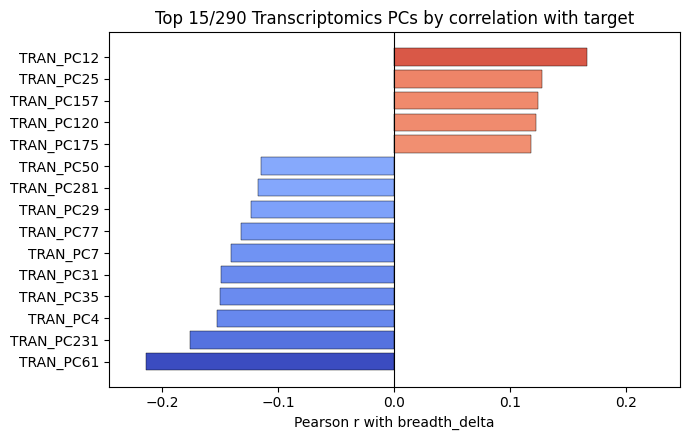

In [34]:
num_to_show = 15
tran_corrs = df_tran[tran_cols + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)
top = tran_corrs.loc[tran_corrs.abs().sort_values(ascending=False).head(num_to_show).index]
top = top.sort_values()

vmax = top.abs().max()
colors = plt.cm.coolwarm((top.values / vmax + 1) / 2)

fig, ax = plt.subplots(figsize=(7, max(4, num_to_show * 0.3)))
ax.barh(top.index, top.values, color=colors, edgecolor='black', linewidth=0.3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel(f'Pearson r with {TARGET_COL}')
ax.set_title(f'Top {num_to_show}/{len(tran_cols)} Transcriptomics PCs by correlation with target')
ax.set_xlim(-vmax * 1.15, vmax * 1.15)
plt.tight_layout()
plt.show()

### Drop sparse features

Drop columns missing in more than `MISSING_THRESHOLD` of rows — too gappy for tree models to learn
from and slow training enough that only GLMs finish.

In [35]:
miss_frac = df.isna().mean()
sparse_cols = miss_frac[miss_frac > MISSING_THRESHOLD].index

if FORCE_KEEP_TRANSCRIPTOMICS:
    cols_to_drop = [c for c in sparse_cols if c != TARGET_COL and c not in tran_cols]
else:
    cols_to_drop = [c for c in sparse_cols if c != TARGET_COL]

df = df.drop(columns=cols_to_drop)
print(f'Dropped {len(cols_to_drop)} columns with >{MISSING_THRESHOLD:.0%} missing.')
print(f'Shape: {df.shape}')

Dropped 102 columns with >80% missing.
Shape: (1581, 365)


In [36]:
surviving_tran = [c for c in df.columns if c.startswith('TRAN_')]
print(f'TRAN columns surviving sparse filter: {len(surviving_tran)} / {len(tran_cols)}')

TRAN columns surviving sparse filter: 290 / 290


### Drop other-task target columns

The challenge participants only have baseline data (demographics + d0 + d7) — d28 and d365
measurements don't exist for them yet. Also drop the constructed `geomean_d28` and `n_strains_*`
columns which are unavailable at prediction time.

In [37]:
leakage_cols = [c for c in df.columns
                if (c.endswith('_d28') and c != TARGET_COL) or c.endswith('_d365')]
leakage_cols += [c for c in ('geomean_d28', 'n_strains_d0', 'n_strains_d28') if c in df.columns]
leakage_cols = list(dict.fromkeys(leakage_cols))
df = df.drop(columns=leakage_cols)
print(f'Dropped {len(leakage_cols)} leakage columns.')
print(f'Final shape: {df.shape}')

Dropped 44 leakage columns.
Final shape: (1581, 321)


In [38]:
# Force float64 on all remaining HAI feature columns to prevent H2O from mistyping
# sparsely-populated columns as categorical, which crashes predict() on the challenge set.
hai_feature_cols = [c for c in df.columns if c.startswith('HAI_') and c != TARGET_COL]
for c in hai_feature_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
    if c in challenge_data.columns:
        challenge_data[c] = pd.to_numeric(challenge_data[c], errors='coerce')
print(f'Forced float64 on {len(hai_feature_cols)} HAI feature columns in training and challenge data.')

Forced float64 on 25 HAI feature columns in training and challenge data.


In [39]:
print(f'Final shape: {df.shape}')
print(f'Target ({TARGET_COL}) stats (log2 delta):\n{df[TARGET_COL].describe()}')
print(f'\ndtype counts:\n{df.dtypes.value_counts()}')

Final shape: (1581, 321)
Target (breadth_delta) stats (log2 delta):
count    1581.000000
mean        0.985069
std         0.922084
min        -1.066667
25%         0.400000
50%         0.800000
75%         1.400000
max         5.600000
Name: breadth_delta, dtype: float64

dtype counts:
float64    318
object       3
Name: count, dtype: int64


---
## AutoML Setup

In [40]:
warnings.filterwarnings('ignore', category=UserWarning, module='h2o')
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,6 hours 30 mins
H2O_cluster_timezone:,America/Los_Angeles
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,9 days
H2O_cluster_name:,H2O_from_python_Brian_gzztjn
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,1.557 Gb
H2O_cluster_total_cores:,4
H2O_cluster_allowed_cores:,4
H2O_cluster_status:,"locked, healthy"


In [41]:
hai_col_types = {c: 'real' for c in hai_feature_cols}
tran_col_types = {c: 'real' for c in surviving_tran}
col_types = {**hai_col_types, **tran_col_types}
data = h2o.H2OFrame(df, column_types=col_types)
print(f'H2OFrame shape: {data.shape}')

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
H2OFrame shape: (1581, 321)


---
## AutoML Training

In [42]:
y = TARGET_COL
x = [c for c in data.columns if c not in (y, 'participant_id')]
print(f'Training samples: {data.nrows}  |  Features: {len(x)}')

aml = H2OAutoML(
    max_models=AUTOML_MAX_MODELS,
    seed=AUTOML_SEED,
    nfolds=5,
    keep_cross_validation_predictions=True,
    max_runtime_secs=AUTO_ML_MAX_RUNTIME_SECONDS,
)

_buf = io.StringIO()
with redirect_stdout(_buf), redirect_stderr(_buf):
    aml.train(x=x, y=y, training_frame=data)
print('Training complete.')

Training samples: 1581  |  Features: 319
Training complete.


In [43]:
lb_df = aml.leaderboard.as_data_frame(use_multi_thread=True)
lb_df

/Users/Brian/miniconda3/envs/python311/lib/python3.11/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,model_id,rmse,mse,mae,rmsle,mean_residual_deviance
0,GBM_1_AutoML_6_20260531_223936,0.818513,0.669964,0.623074,NaN,0.669964
1,GLM_1_AutoML_6_20260531_223936,0.842961,0.710584,0.641517,NaN,0.710584
2,XGBoost_1_AutoML_6_20260531_223936,0.901449,0.812611,0.695064,NaN,0.812611
3,XGBoost_2_AutoML_6_20260531_223936,0.906264,0.821315,0.692529,NaN,0.821315


/Users/Brian/miniconda3/envs/python311/lib/python3.11/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/Users/Brian/miniconda3/envs/python311/lib/python3.11/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/Users/Brian/miniconda3/envs/python311/lib/python3.11/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using si

Prediction model:  GBM_1_AutoML_6_20260531_223936
Scoring model:     GBM_1_AutoML_6_20260531_223936
Task 4.5 — Spearman on final geomean D28 (best base model 5-fold CV): 0.781  (p=0.0000)


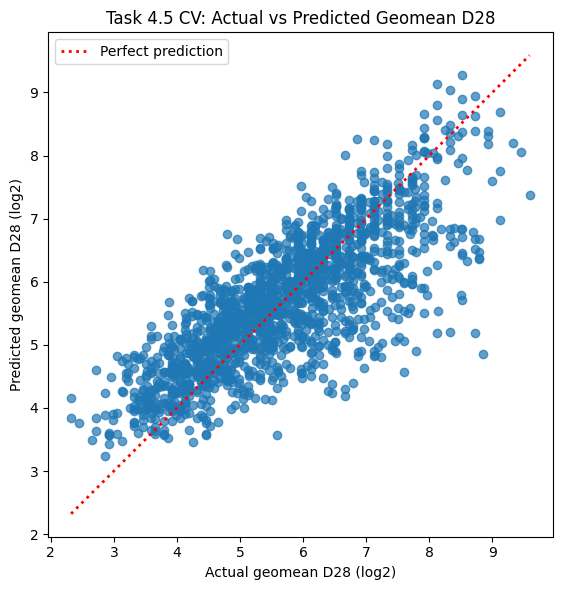

In [44]:
# Best overall (may be a StackedEnsemble) — used for predictions and saved as the deliverable
top_model = h2o.get_model(lb_df['model_id'].iloc[0])

# Best non-ensemble — used for Spearman CV and varimp, since StackedEnsembles don't expose
# cross-validation holdout predictions in the same way base models do.
top_base_model_id = lb_df[~lb_df['model_id'].str.contains('StackedEnsemble')]['model_id'].iloc[0]
top_base_model = h2o.get_model(top_base_model_id)

cv_pred_delta = top_base_model.cross_validation_holdout_predictions().as_data_frame(use_multi_thread=True)['predict']
actual_delta = data[y].as_data_frame(use_multi_thread=True)[y]
baseline_geomean_d0 = data['geomean_d0'].as_data_frame(use_multi_thread=True)['geomean_d0']

actual_geomean_d28 = baseline_geomean_d0 + actual_delta
pred_geomean_d28 = baseline_geomean_d0 + cv_pred_delta
valid_eval = actual_geomean_d28.notna() & pred_geomean_d28.notna()

rho, pval = spearmanr(actual_geomean_d28[valid_eval], pred_geomean_d28[valid_eval])
print(f'Prediction model:  {top_model.model_id}')
print(f'Scoring model:     {top_base_model.model_id}')
print(f'Task 4.5 — Spearman on final geomean D28 (best base model 5-fold CV): {rho:.3f}  (p={pval:.4f})')

axis_min = min(actual_geomean_d28[valid_eval].min(), pred_geomean_d28[valid_eval].min())
axis_max = max(actual_geomean_d28[valid_eval].max(), pred_geomean_d28[valid_eval].max())

plt.figure(figsize=(6, 6))
plt.scatter(actual_geomean_d28[valid_eval], pred_geomean_d28[valid_eval], alpha=0.7)
plt.plot([axis_min, axis_max], [axis_min, axis_max], color='red', linestyle=':', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual geomean D28 (log2)')
plt.ylabel('Predicted geomean D28 (log2)')
plt.title('Task 4.5 CV: Actual vs Predicted Geomean D28')
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

Best base model: GBM_1_AutoML_6_20260531_223936


,variable,relative_importance,scaled_importance,percentage
0,HAI_Yam B/Florida/4/2006_d0,379.589355,1.000000,0.163439
1,HAI_H3N2 A/Texas/50/2012_d0,343.769562,0.905635,0.148016
2,geomean_d0,232.501724,0.612509,0.100108
3,PART_age,222.647156,0.586547,0.095865
4,HAI_Vic B/Colorado/6/2017_d0,144.416809,0.380455,0.062181
5,HAI_Vic B/Brisbane/60/2008_d0,90.710197,0.238969,0.039057
6,HAI_H3N2 A/Hong Kong/4801/2014_d0,86.365852,0.227524,0.037186
7,HAI_H1N1 A/Michigan/45/2015_d0,81.105682,0.213667,0.034922
8,HAI_H3N2 A/Panama/2007/1999_d0,71.414276,0.188136,0.030749
9,HAI_Vic B/Washington/2/2019_d0,71.263077,0.187737,0.030684


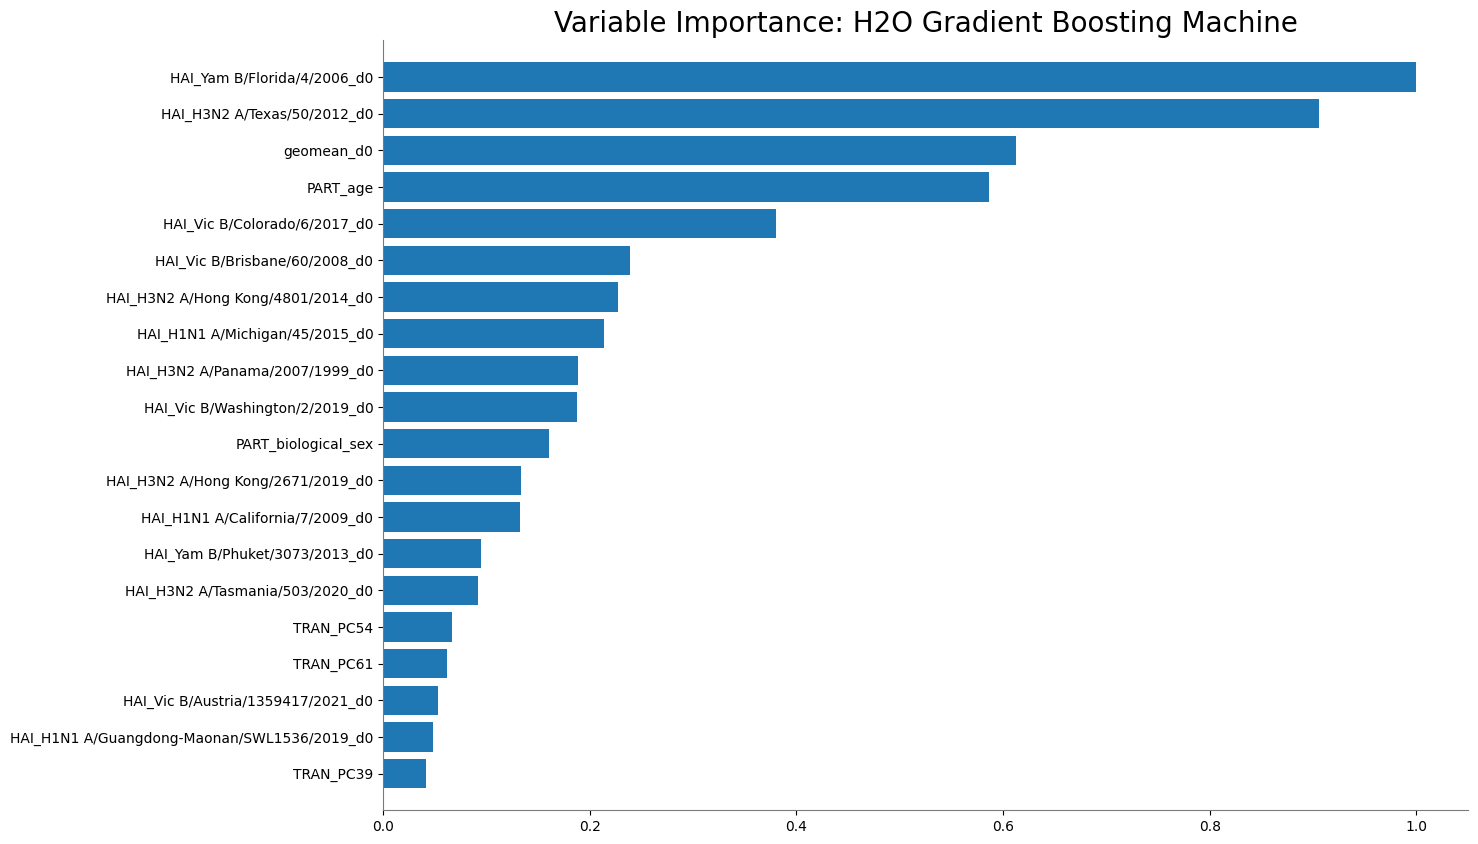

<Figure size 640x480 with 0 Axes>

In [45]:
print(f'Best base model: {top_base_model.model_id}')
varimp = top_base_model.varimp(use_pandas=True)
display(varimp.head(20))
top_base_model.varimp_plot(num_of_features=20)

In [46]:
challenge_col_types = {c: 'real' for c in hai_feature_cols if c in challenge_data.columns}
challenge_col_types.update({c: 'real' for c in surviving_tran if c in challenge_data.columns})
challenge_hf = h2o.H2OFrame(challenge_data, column_types=challenge_col_types)
y_pred = top_model.predict(challenge_hf).as_data_frame(use_multi_thread=True)['predict']

challenge_geomean_d0 = challenge_data['geomean_d0'].values

results = pd.DataFrame({
    'Participant_ID': challenge_data['participant_id'].values,
    'Task_4.5': np.exp2(challenge_geomean_d0 + y_pred),
})
results.to_csv(f'{SUBMISSION_PATH}/task_4_5.csv', index=False)
results

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


/Users/Brian/miniconda3/envs/python311/lib/python3.11/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,Participant_ID,Task_4.5
0,2024_UGA.ID_077,19.773891
1,2024_UGA.ID_086,38.572934
2,2024_UGA.ID_128,104.275733
3,2024_UGA.ID_170,26.680341
4,2024_UGA.ID_179,31.819361
5,2024_UGA.ID_215,50.659069
6,2024_UGA.ID_219,44.768167
7,2024_UGA.ID_275,20.523614
8,2024_UGA.ID_295,32.223867
9,2024_UGA.ID_296,12.337121


In [47]:
model_path = h2o.save_model(model=top_model, path='.', filename='models/model_4.5', force=True)
print(f'Model saved to: {model_path}')

Model saved to: /Users/Brian/Desktop/2024-b6hill/DSE260/cmi-flu-prediction-challenge-capstone/automl_models/models/model_4.5


In [48]:
h2o.cluster().shutdown()

H2O session _sid_8abd closed.


---
## Conclusion

- **Leader model:** TBD (re-run to populate)
- **Scoring model:** TBD (best non-StackedEnsemble base, used for CV Spearman)
- **CV Spearman:** TBD
- **Training samples:** TBD | **Features:** TBD
- **Model saved:** `automl_models/models/model_4.5`

**Target:** `breadth_delta` = log2(geomean HAI D28) − log2(geomean HAI D0) across up to 16/17
challenge strains with D28 data in training. `H3N2 A/Massachusetts/18/2022` has no D28 data and
is excluded from D28 averaging. Only participants with ≥ `MIN_STRAINS` strains at both timepoints
are included as training rows.

**Output:** `np.exp2(geomean_d0_challenge + predicted_breadth_delta)` — raw geometric mean HAI
titer at D28 for each challenge participant.

**Feature set:** demographics + HAI d0/d7 columns + TRAN PCs from `combined.csv`, after dropping
columns >80% missing and all d28/d365 leakage columns. `FORCE_KEEP_TRANSCRIPTOMICS = True`
preserves all TRAN PCs regardless of sparsity. All HAI and TRAN columns are explicitly typed
`real` on both training and challenge H2OFrames to prevent auto-type mismatches.

**Imputation note:** No manual imputation. H2O's tree models handle `NaN` natively at each split,
eliminating leakage that would arise from pre-computing medians on the full training set.

Submission saved to `submission/task_4_5.csv`.

To reload the model: `h2o.load_model('automl_models/models/model_4.5')`